# Refine Best Performing Fine-Tuned Bert Model

## Step 1: Data Load

In [1]:
import os
import pandas as pd
reduced_data_path = f"{'/'.join(os.getcwd().split('/')[:-1])}/data/reduced_twitter_data.csv"
df = pd.read_csv(reduced_data_path)

Create a wrapper for model evaluation:

In [66]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, roc_auc_score, precision_score, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

class ModelEvaluator():
    def __init__(self, fit_model=None, pipe=None):
        self.model = fit_model
        self.pipe = pipe
        self.false_positives = []
        self.false_negatives = []
    
    def eval_model(self, X_test, y_test, labels):
        assert self.model is not None
        self.novel_x = X_test
        self.novel_y = y_test
        self.labels = labels
        
        self.predictions = self.model.predict(X_test)

        self.reclassified_predictions = []

        for pred in self.predictions:
            if pred >= 0.5:
                self.reclassified_predictions.append(1)
            else:
                self.reclassified_predictions.append(0)

        self.confusion_matrix = {
            'true_positive':0,
            'false_positive':0,
            'true_negative':0,
            'false_negative':0
        }

        for i, dir in enumerate(self.novel_y):
            if self.reclassified_predictions[i] == 1 and dir == 0:
                self.confusion_matrix['false_positive']+=1
            elif self.reclassified_predictions[i] == 1 and dir == 1:
                self.confusion_matrix['true_positive']+=1
            elif self.reclassified_predictions[i] == 0 and dir == 1:
                self.confusion_matrix['false_negative']+=1
            elif self.reclassified_predictions[i] == 0 and dir == 0:
                self.confusion_matrix['true_negative'] += 1

        self.cm_array = np.array([[self.confusion_matrix['true_negative'], self.confusion_matrix['false_positive']],
                                    [self.confusion_matrix['false_negative'], self.confusion_matrix['true_positive']]])

        self._describe_predictions()
        self._compute_metrics()
        self._plot_cm()

    def eval_pipe(self, X_test:list[str], y_test:list[int], labels):
        assert self.pipe is not None
        self.novel_x = X_test
        self.novel_y = y_test
        self.labels = labels
        
        self.predictions = self.pipe(X_test)

        self.reclassified_predictions = []

        for pred in self.predictions:
            if pred['label']=='LABEL_0':
                self.reclassified_predictions.append(0)
            else:
                self.reclassified_predictions.append(1)
    
        self.confusion_matrix = {
            'true_positive':0,
            'false_positive':0,
            'true_negative':0,
            'false_negative':0
        }

        for i, dir in enumerate(self.novel_y):
            if self.reclassified_predictions[i] == 1 and dir == 0:
                self.confusion_matrix['false_positive']+=1
                self.false_positives.append(self.novel_x[i])
            elif self.reclassified_predictions[i] == 1 and dir == 1:
                self.confusion_matrix['true_positive']+=1
            elif self.reclassified_predictions[i] == 0 and dir == 1:
                self.confusion_matrix['false_negative']+=1
                self.false_negatives.append(self.novel_x[i])
            elif self.reclassified_predictions[i] == 0 and dir == 0:
                self.confusion_matrix['true_negative'] += 1

        self.cm_array = np.array([[self.confusion_matrix['true_negative'], self.confusion_matrix['false_positive']],
                                    [self.confusion_matrix['false_negative'], self.confusion_matrix['true_positive']]])

        self._describe_predictions()
        self._compute_metrics()
        self._plot_cm()

    def _describe_predictions(self):
        print(f'Number of {self.labels[1]} Predictions: {self.confusion_matrix[f'true_positive'] + self.confusion_matrix['false_positive']}')
        print(f'Number of {self.labels[0]} Predictions: {self.confusion_matrix['true_negative'] + self.confusion_matrix['false_negative']}')
        print(f'Percent {self.labels[1]} Predictions: {((self.confusion_matrix['true_positive'] + self.confusion_matrix['false_positive'])/len(self.novel_y))*100}')
        print(f'Percent {self.labels[0]} Predictions: {((self.confusion_matrix['true_negative'] + self.confusion_matrix['false_negative'])/len(self.novel_y))*100}')

    def _plot_cm(self):
        fig, axes = plt.subplots(1,2,figsize=(15,10))
        axes = axes.flatten()

        cm = ConfusionMatrixDisplay(
        confusion_matrix=self.cm_array,
        display_labels=self.labels
        )

        cm.plot(cmap=plt.cm.Blues,ax=axes[0])

        axes[0].set_title('Confusion Matrix')
        axes[0].set_xlabel('Predicted Label')
        axes[0].set_ylabel('True Label')


        axes[1].plot(self.fpr, self.tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {self.auc:.2f})')
        axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance')
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
        axes[1].legend(loc="lower right")
        axes[1].grid(True)

        plt.show()

    def _compute_metrics(self):
        # Calculate the ROC curve points
        self.fpr, self.tpr, self.thresholds = roc_curve(self.novel_y, self.reclassified_predictions)

        # Calculate the AUC
        self.auc = roc_auc_score(self.novel_y, self.reclassified_predictions)

        self.accuracy = f'{accuracy_score(self.novel_y, self.reclassified_predictions)*100:.2f}%'

        # Compute recall
        self.recall = self.confusion_matrix['true_positive'] / (self.confusion_matrix['true_positive'] + self.confusion_matrix['false_negative'])

        # Compute precision
        self.precision = precision_score(self.novel_y, self.reclassified_predictions)

        # Compute F1-Score
        self.f1_score = f'{(2*self.precision*self.recall)/(self.precision+self.recall):.2f}'

        print(f'\nAccuracy: {self.accuracy}')
        print(f'\nRecall: {self.recall}')
        print(f'\nPrecision: {self.precision}')
        print(f'\nF1-Score: {self.f1_score}')

### Advanced Model Training and In-Depth Testing

I prefer to use a wrapper around the training framework to make extensive testing a little more clean.

In [74]:
from transformers import TrainingArguments, DataCollatorWithPadding, Trainer, AutoTokenizer, BertForSequenceClassification, logging
import re
import emoji
import torch

logging.set_verbosity_error() 

class ModelTrainer():
    def __init__(self, checkpoint, dataset, input_max_len, epochs, path='model', optim='adamw_hf', trainable_layers=[], batch_size=8, freeze_transformer=False, text_preprocess = False) -> None:
        self.input_max_len = input_max_len
        self.checkpoint = checkpoint
        self.dataset = dataset
        self.tokenizer = AutoTokenizer.from_pretrained(self.checkpoint)
        self.model = BertForSequenceClassification.from_pretrained(self.checkpoint)
        self.epochs = epochs
        self.path = f"./results/{path}"
        self.optim = optim
        self.trainable_layers = trainable_layers
        self.batch_size = batch_size
        self.freeze_transformer = freeze_transformer
        self.text_preprocess = text_preprocess

    def _text_preprocess(self, text):
        # Lowercase
        text = text.lower()
        #convert emojis
        text = emoji.demojize(text, delimiters=("",""), language='alias')
        # Remove handles
        text = re.sub(r'\B@\S+','',text)
        return text

    def _preprocess_function(self, examples):
        if self.text_preprocess:
            model_inputs = self.tokenizer([self._text_preprocess(text) for text in examples["Text"]],
                                    max_length=self.input_max_len, # Choose 512 for articles
                                    truncation=True,)
        else:
            model_inputs = self.tokenizer(examples["Text"],
                                    max_length=self.input_max_len, # Choose 512 for articles
                                    truncation=True,)

        # We use a list comprehension to iterate through the batch of labels
        model_inputs["labels"] = examples["Sentiment"]

        return model_inputs

    def _set_trainable_layers(self):
        if len(self.trainable_layers):
            for name, param in self.model.named_parameters():
                # Check if the parameter name contains any of the strings in our list
                if any(trainable_layer in name for trainable_layer in self.trainable_layers):
                    param.requires_grad = True  # Keep trainable
                else:
                    param.requires_grad = False # Freeze

    def train(self):
        train_data = self.dataset['train'].map(self._preprocess_function, batched=True)
        test_data = self.dataset['test'].map(self._preprocess_function, batched=True)

        self._set_trainable_layers()

        if self.freeze_transformer:
            for param in self.model.bert.parameters():
                param.requires_grad = False

        assert not os.path.exists(self.path)
 
        output_dir = self.path

        training_args = TrainingArguments(
            output_dir=output_dir,
            learning_rate=5e-5,        # Hint: 5e-5 is standard for BART
            num_train_epochs=self.epochs,     # Hint: 3 to 5 is sufficient
            per_device_train_batch_size=self.batch_size,
            optim=self.optim,
            fp16=torch.cuda.is_available(),
        )

        data_collator = DataCollatorWithPadding(
            tokenizer=self.tokenizer,
            padding="longest",
            max_length=self.input_max_len
        )

        # Category B Scaffold: Initialization of the Trainer API
        trainer = Trainer(
            model=self.model,
            args=training_args,
            train_dataset=train_data,
            eval_dataset=test_data,
            data_collator=data_collator
        )

        # Train the model
        trainer.train()
        self.tokenizer.save_pretrained(self.path)

In [4]:
import json
from sklearn.model_selection import train_test_split

def save_bert_data(df, train_path, test_path):
    # Store the sentiment as a binary value
    df['senitment'] = df['sentiment'].replace(4,1)
    y = np.array(df['senitment'])

    # Store the data in separate text files to be read in by the datasets package
    X_train_raw, X_test_raw, y_train, y_test = train_test_split([text for text in df["text"].values], y, test_size=0.3, random_state=42)

    train_data = {"type": "train",
                "data":[]
                }

    test_data = {
                "type": "test",
                "data":[]
                }

    for i in range(len(X_train_raw)):
        train_data["data"].append(
            {
                "Text":X_train_raw[i],
                "Sentiment":int(y_train[i])
        })

    for i in range(len(X_test_raw)):
        test_data["data"].append(
            {
                "Text":X_test_raw[i],
                "Sentiment":int(y_test[i])
        })

    # Save Data
    with open(train_path, 'w+') as f:
        json.dump(train_data, f)

    with open(test_path, 'w+') as f:
        json.dump(test_data, f)

In [5]:
from datasets import load_dataset

train_path = f"{'/'.join(os.getcwd().split('/')[:-1])}/data/train.json"
test_path = f"{'/'.join(os.getcwd().split('/')[:-1])}/data/test.json"

save_bert_data(df, train_path, test_path)

# Load from CSV
dataset = load_dataset("json", data_files={"train": train_path, "test": test_path}, field="data")


Generating train split: 35000 examples [00:00, 546190.23 examples/s]
Generating test split: 15000 examples [00:00, 693540.87 examples/s]


Train a model using the best configuration from the preliminary results phase. This will be the baseline. 

In [140]:
base_model_checkpoint = 'google-bert/bert-base-uncased'

ft_base_model_full = ModelTrainer(base_model_checkpoint, dataset, 512, 3, path='base_ft_model')
ft_base_model_full.train()

Map: 100%|██████████| 15000/15000 [-00:01<00:00, -9138.01 examples/s]
/home/water/Grad School/DSE6212/.venv/lib/python3.12/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


{'loss': 0.5654, 'grad_norm': 7.221181869506836, 'learning_rate': 4.8106666666666665e-05, 'epoch': 0.11428571428571428}
{'loss': 0.4984, 'grad_norm': 10.161232948303223, 'learning_rate': 4.620190476190476e-05, 'epoch': 0.22857142857142856}
{'loss': 0.47, 'grad_norm': 7.617056846618652, 'learning_rate': 4.4297142857142856e-05, 'epoch': 0.34285714285714286}
{'loss': 0.4617, 'grad_norm': 4.905759811401367, 'learning_rate': 4.239238095238096e-05, 'epoch': 0.45714285714285713}
{'loss': 0.4734, 'grad_norm': 2.619180679321289, 'learning_rate': 4.049142857142857e-05, 'epoch': 0.5714285714285714}
{'loss': 0.4817, 'grad_norm': 9.350759506225586, 'learning_rate': 3.858666666666667e-05, 'epoch': 0.6857142857142857}
{'loss': 0.4377, 'grad_norm': 19.254249572753906, 'learning_rate': 3.668190476190476e-05, 'epoch': 0.8}
{'loss': 0.4435, 'grad_norm': 11.481649398803711, 'learning_rate': 3.477714285714286e-05, 'epoch': 0.9142857142857143}
{'loss': 0.4158, 'grad_norm': 16.514039993286133, 'learning_rate

Train the model with a batch size of 32 instead of the default 8.

In [141]:
base_model_checkpoint = 'google-bert/bert-base-uncased'

base_w_batch_32 = ModelTrainer(base_model_checkpoint, dataset, 512, 3, batch_size=32, path = 'ft_batch_size_32')
base_w_batch_32.train()

Map: 100%|██████████| 15000/15000 [00:00<00:00, 26392.07 examples/s]
/home/water/Grad School/DSE6212/.venv/lib/python3.12/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


{'loss': 0.4561, 'grad_norm': 5.5729804039001465, 'learning_rate': 4.239792809262645e-05, 'epoch': 0.4570383912248629}
{'loss': 0.3984, 'grad_norm': 3.029215097427368, 'learning_rate': 3.47958561852529e-05, 'epoch': 0.9140767824497258}
{'loss': 0.2804, 'grad_norm': 3.832876205444336, 'learning_rate': 2.7178549664838517e-05, 'epoch': 1.3711151736745886}
{'loss': 0.2491, 'grad_norm': 4.0863142013549805, 'learning_rate': 1.956124314442413e-05, 'epoch': 1.8281535648994516}
{'loss': 0.1665, 'grad_norm': 8.922954559326172, 'learning_rate': 1.1943936624009751e-05, 'epoch': 2.2851919561243146}
{'loss': 0.1147, 'grad_norm': 1.9022626876831055, 'learning_rate': 4.341864716636198e-06, 'epoch': 2.742230347349177}
{'train_runtime': 152.9711, 'train_samples_per_second': 686.404, 'train_steps_per_second': 21.455, 'train_loss': 0.26426585195705266, 'epoch': 3.0}


In [142]:
base_model_checkpoint = 'google-bert/bert-base-uncased'

base_w_batch_64 = ModelTrainer(base_model_checkpoint, dataset, 512, 3, batch_size=64, path = 'ft_batch_size_64')
base_w_batch_64.train()

Map: 100%|██████████| 15000/15000 [00:00<00:00, 25108.05 examples/s]
/home/water/Grad School/DSE6212/.venv/lib/python3.12/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


{'loss': 0.4255, 'grad_norm': 2.5889742374420166, 'learning_rate': 3.476538695917124e-05, 'epoch': 0.9140767824497258}
{'loss': 0.2689, 'grad_norm': 3.979804515838623, 'learning_rate': 1.9530773918342475e-05, 'epoch': 1.8281535648994516}
{'loss': 0.1511, 'grad_norm': 4.340104579925537, 'learning_rate': 4.326630103595368e-06, 'epoch': 2.742230347349177}
{'train_runtime': 95.4726, 'train_samples_per_second': 1099.792, 'train_steps_per_second': 17.188, 'train_loss': 0.2683297261314229, 'epoch': 3.0}


# Testing Fine-Tuned Models

In [ ]:
# Load novel data
def get_novel_data(input_file, train_data_path=f"{'/'.join(os.getcwd().split('/')[:-1])}/data/reduced_twitter_data.csv", sample_size=15000):
    """
    Reduces the Sentiment140 dataset while maintaining class balance.
    Columns: 0: target, 1: id, 2: date, 3: flag, 4: user, 5: text
    """

    cols = ["sentiment", "id", "date", "query", "user", "text"]

    print("Reading dataset in chunks...")
    # Using 'latin-1' encoding as this dataset often has special characters
    chunks = pd.read_csv(input_file, encoding='latin-1', header=None, names=cols, chunksize=500000)

    df_list = []
    counter = 1
    for chunk in chunks:
        # Keep only necessary columns to save memory immediately
        df_list.append(chunk[['sentiment', 'text']])
        print(f'Saving Chunk {counter}')
        counter+=1

    full_df = pd.concat(df_list)

    # Stratified sampling: Ensure 50/50 split of Positive (4) and Negative (0)
    # The dataset uses 0=negative, 2=neutral (rare), 4=positive
    negative_tweets = full_df[full_df['sentiment'] == 0].sample(n=sample_size//2, random_state=85)
    positive_tweets = full_df[full_df['sentiment'] == 4].sample(n=sample_size//2, random_state=85)

    reduced_df = pd.concat([negative_tweets, positive_tweets]).sample(frac=1).reset_index(drop=True)

    train_df = pd.read_csv(train_data_path)

    # Select only rows not in the training data
    unique_rows = reduced_df[~reduced_df['text'].isin(train_df['text'])].copy()

    unique_rows['sentiment']=unique_rows['sentiment'].replace(4,1)

    return unique_rows.reset_index(drop=True)

In [56]:
val_data = get_novel_data(f"{'/'.join(os.getcwd().split('/')[:-1])}/data/original_twitter_data.csv")

Reading dataset in chunks...


In [57]:
len(val_data)

14468

In [62]:
from transformers import pipeline
from transformers import AutoTokenizer
from time import time

def test_model(check_path, val_data):

    checkpoints = sorted([path.split("-")[-1] for path in os.listdir(check_path) if "checkpoint" in path], reverse=True)
    # Select the last major checkpoint.
    model_checkpoint = f'{check_path}/checkpoint-{checkpoints[1]}'

    tokenizer = AutoTokenizer.from_pretrained(check_path)
    model = BertForSequenceClassification.from_pretrained(model_checkpoint)

    #Set up the analysis pipe
    pipe = pipeline(task="sentiment-analysis", model=model, tokenizer=tokenizer, device='cuda')
    pipe_evaluator = ModelEvaluator(pipe=pipe)

    labels = ["Negative", "Positive"]
    X_val = list(val_data['text'].values)
    y_val = np.array(val_data['sentiment'])

    start = time()
    pipe_evaluator.eval_pipe(X_test=X_val, y_test=y_val, labels=labels)
    end = time()
    print(f'Inference Time: {end-start}')

    return pipe_evaluator

Number of Positive Predictions: 6797
Number of Negative Predictions: 7671
Percent Positive Predictions: 46.97954105612386
Percent Negative Predictions: 53.020458943876136

Accuracy: 82.96%

Recall: 0.7994194083494609

Precision: 0.8508165367073709

F1-Score: 0.82


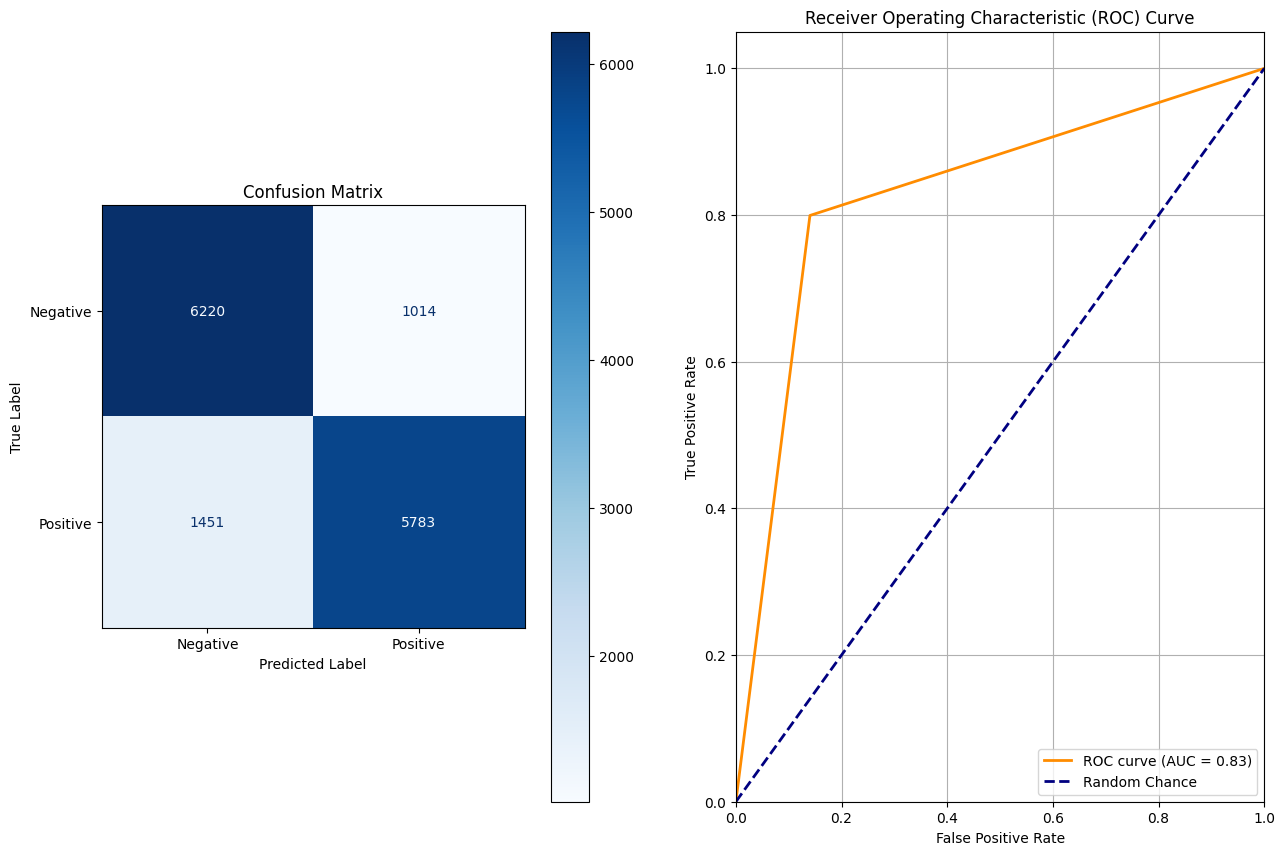

Inference Time: 60.093812465667725


In [63]:
base_ft_checkpoint = 'results/base_ft_model'
test_model(base_ft_checkpoint, val_data)

Number of Positive Predictions: 7134
Number of Negative Predictions: 7334
Percent Positive Predictions: 49.30881946364391
Percent Negative Predictions: 50.69118053635609

Accuracy: 83.48%

Recall: 0.8278960464473321

Precision: 0.8395009812167087

F1-Score: 0.83


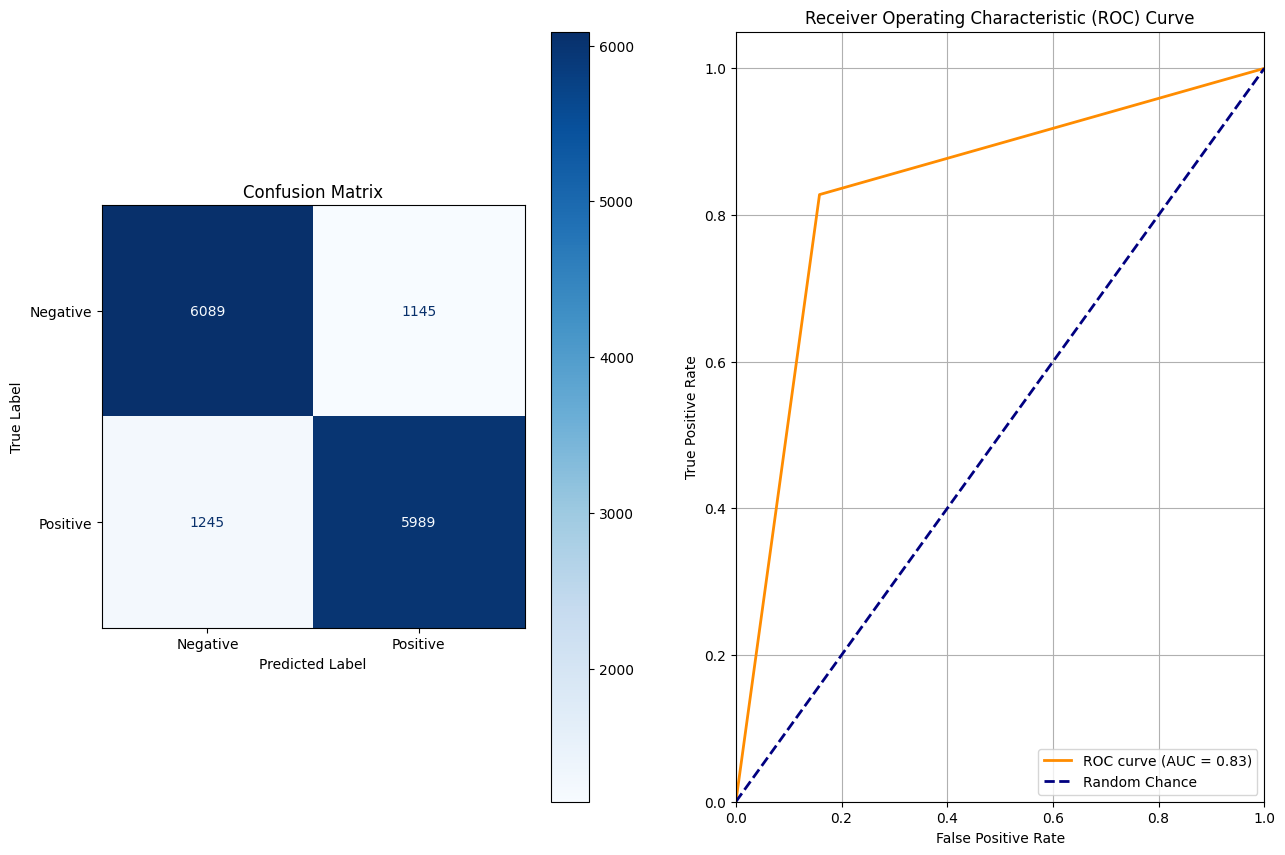

Inference Time: 63.428136110305786


In [149]:
batch_32_checkpoint = 'results/ft_batch_size_32'

test_model(batch_32_checkpoint, val_data)

Number of Positive Predictions: 7188
Number of Negative Predictions: 7280
Percent Positive Predictions: 49.682056953276195
Percent Negative Predictions: 50.3179430467238

Accuracy: 83.76%

Recall: 0.8343931434890793

Precision: 0.8397328881469115

F1-Score: 0.84


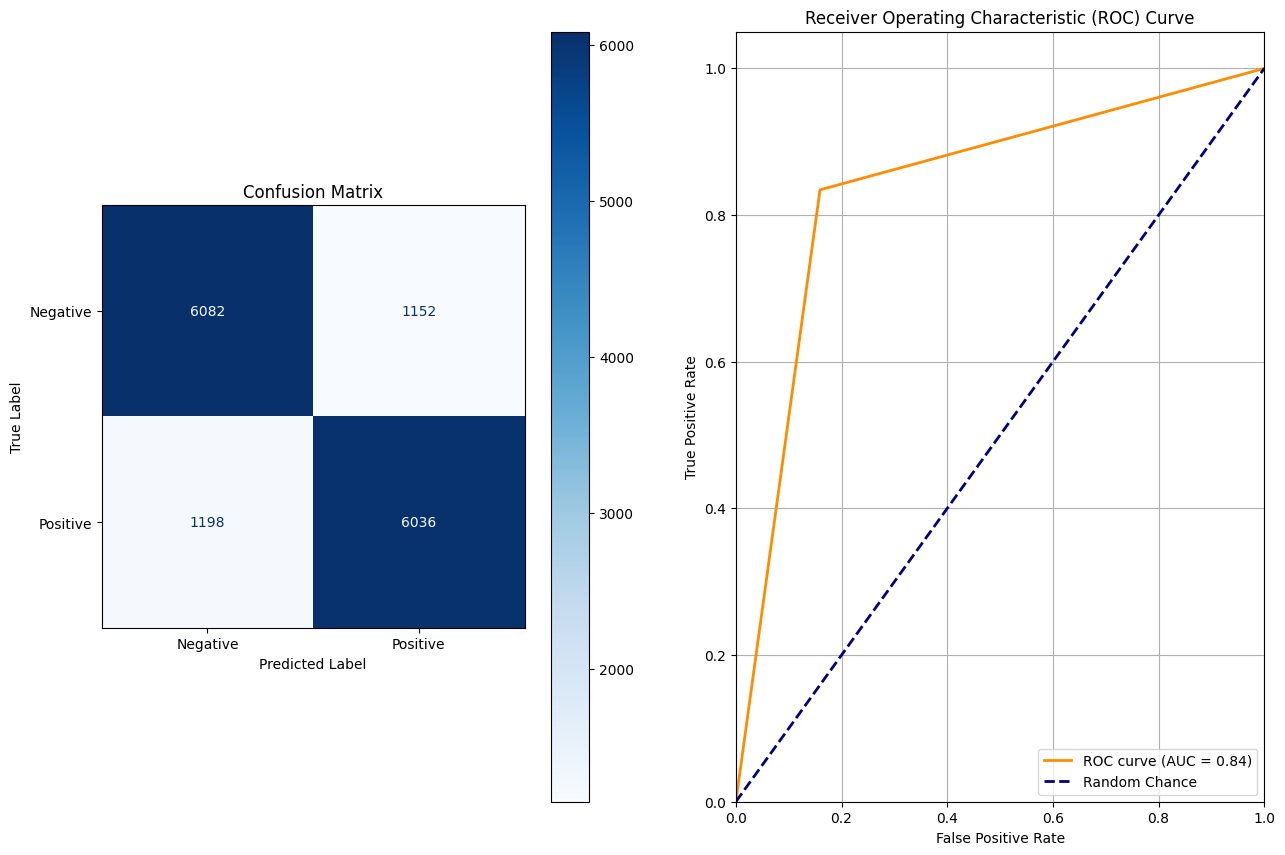

Inference Time: 78.20963621139526


In [150]:
batch_64_checkpoint = 'results/ft_batch_size_64'

test_model(batch_64_checkpoint, val_data)

# Experiment with Max Input Length

In [156]:
base_model_checkpoint = 'google-bert/bert-base-uncased'

batch_64_input_2048 = ModelTrainer(base_model_checkpoint, dataset, 2048, 3, batch_size=64, path = 'batch_64_input_2048')
batch_64_input_2048.train()

Map: 100%|██████████| 15000/15000 [00:00<00:00, 23845.97 examples/s]
/home/water/Grad School/DSE6212/.venv/lib/python3.12/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


{'loss': 0.4228, 'grad_norm': 2.6864540576934814, 'learning_rate': 3.47958561852529e-05, 'epoch': 0.9140767824497258}
{'loss': 0.2698, 'grad_norm': 4.085620880126953, 'learning_rate': 1.956124314442413e-05, 'epoch': 1.8281535648994516}
{'loss': 0.1547, 'grad_norm': 5.366917133331299, 'learning_rate': 4.326630103595368e-06, 'epoch': 2.742230347349177}
{'train_runtime': 180.2225, 'train_samples_per_second': 582.613, 'train_steps_per_second': 9.105, 'train_loss': 0.26920628939947655, 'epoch': 3.0}


Number of Positive Predictions: 7081
Number of Negative Predictions: 7387
Percent Positive Predictions: 48.94249377937518
Percent Negative Predictions: 51.05750622062482

Accuracy: 84.04%

Recall: 0.8298313519491292

Precision: 0.8477616155910183

F1-Score: 0.84


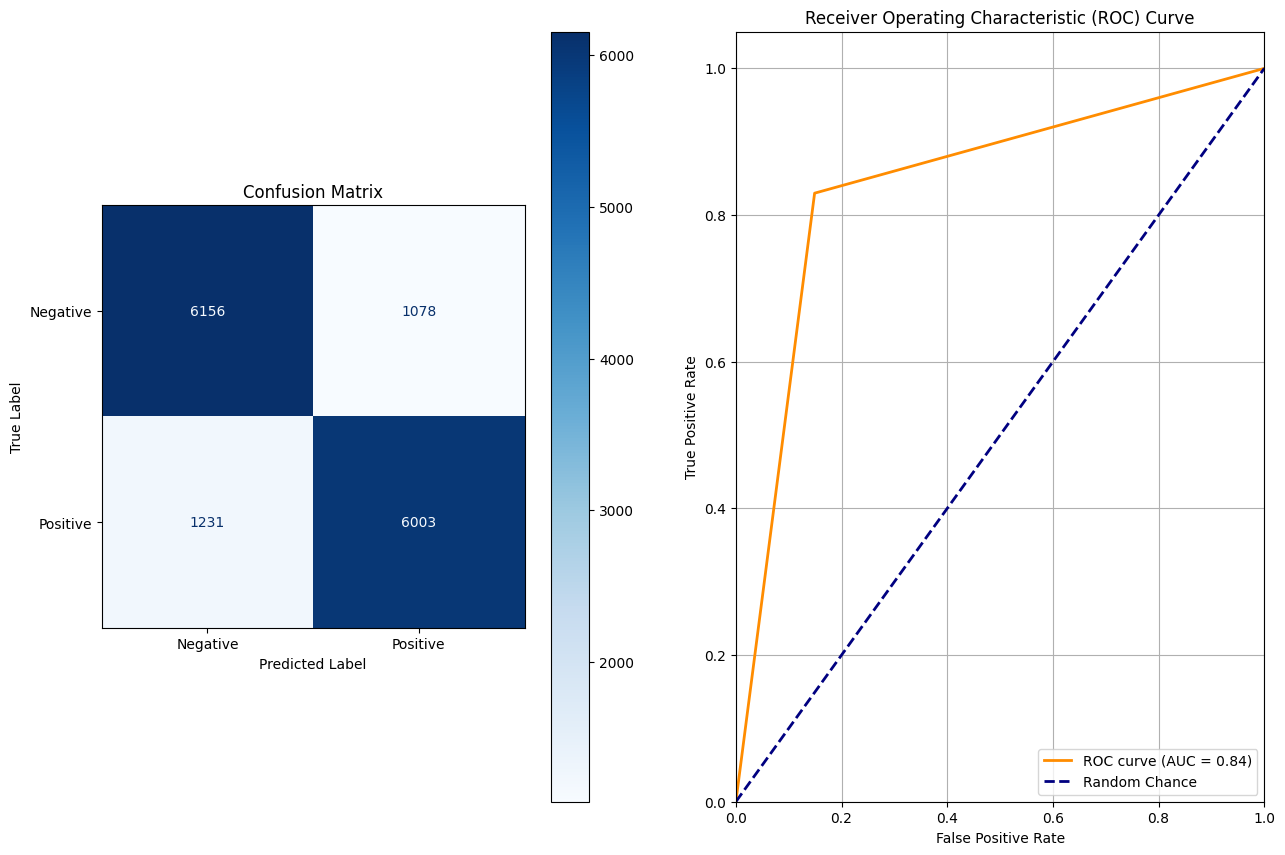

Inference Time: 64.4789719581604


In [157]:
batch_64_input_2048_checkpoint = 'results/batch_64_input_2048'

test_model(batch_64_input_2048_checkpoint, val_data)

In [158]:
base_model_checkpoint = 'google-bert/bert-base-uncased'

batch_64_input_1024 = ModelTrainer(base_model_checkpoint, dataset, 1024, 3, batch_size=64, path = 'batch_64_input_1024')
batch_64_input_1024.train()

Map: 100%|██████████| 15000/15000 [00:00<00:00, 16290.59 examples/s]
/home/water/Grad School/DSE6212/.venv/lib/python3.12/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


{'loss': 0.4235, 'grad_norm': 2.5955898761749268, 'learning_rate': 3.476538695917124e-05, 'epoch': 0.9140767824497258}
{'loss': 0.2699, 'grad_norm': 4.5152459144592285, 'learning_rate': 1.9530773918342475e-05, 'epoch': 1.8281535648994516}
{'loss': 0.1534, 'grad_norm': 5.242021083831787, 'learning_rate': 4.326630103595368e-06, 'epoch': 2.742230347349177}
{'train_runtime': 213.7241, 'train_samples_per_second': 491.288, 'train_steps_per_second': 7.678, 'train_loss': 0.2694458912088695, 'epoch': 3.0}


Number of Positive Predictions: 7209
Number of Negative Predictions: 7259
Percent Positive Predictions: 49.82720486591097
Percent Negative Predictions: 50.17279513408902

Accuracy: 83.70%

Recall: 0.8352225601327067

Precision: 0.8381190178942988

F1-Score: 0.84


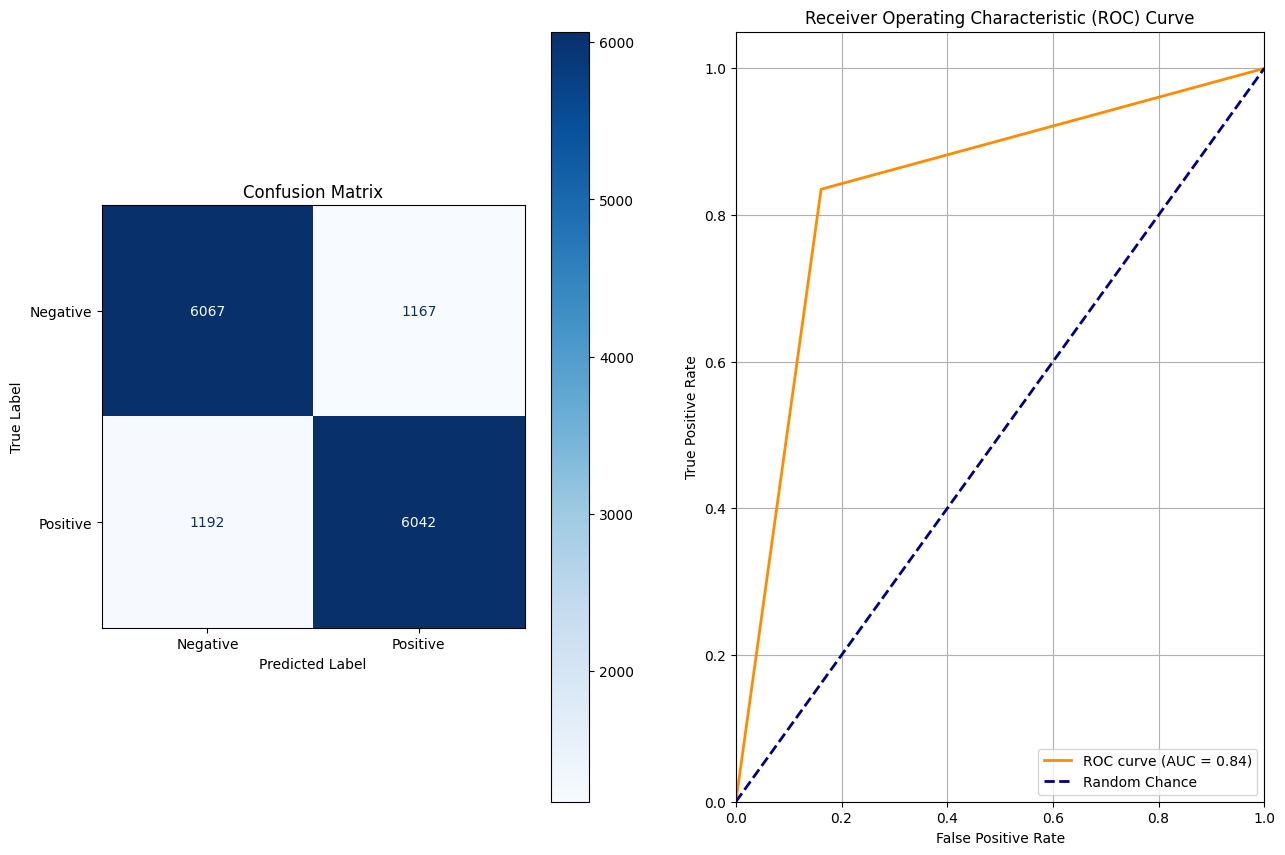

Inference Time: 63.9964759349823


In [159]:
batch_64_input_1024_checkpoint = 'results/batch_64_input_1024'

test_model(batch_64_input_1024_checkpoint, val_data)

In [160]:
base_model_checkpoint = 'google-bert/bert-base-uncased'

batch_64_input_512 = ModelTrainer(base_model_checkpoint, dataset, 512, 3, batch_size=64, path = 'batch_64_input_512')
batch_64_input_512.train()

Map: 100%|██████████| 15000/15000 [00:00<00:00, 17181.93 examples/s]
/home/water/Grad School/DSE6212/.venv/lib/python3.12/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


{'loss': 0.4233, 'grad_norm': 2.46211576461792, 'learning_rate': 3.476538695917124e-05, 'epoch': 0.9140767824497258}
{'loss': 0.2698, 'grad_norm': 4.476372718811035, 'learning_rate': 1.9530773918342475e-05, 'epoch': 1.8281535648994516}
{'loss': 0.1525, 'grad_norm': 5.428554534912109, 'learning_rate': 4.296160877513712e-06, 'epoch': 2.742230347349177}
{'train_runtime': 97.6644, 'train_samples_per_second': 1075.111, 'train_steps_per_second': 16.802, 'train_loss': 0.2691017292680572, 'epoch': 3.0}


Number of Positive Predictions: 7212
Number of Negative Predictions: 7256
Percent Positive Predictions: 49.84794028200166
Percent Negative Predictions: 50.15205971799834

Accuracy: 83.90%

Recall: 0.8374343378490462

Precision: 0.8399889073765946

F1-Score: 0.84


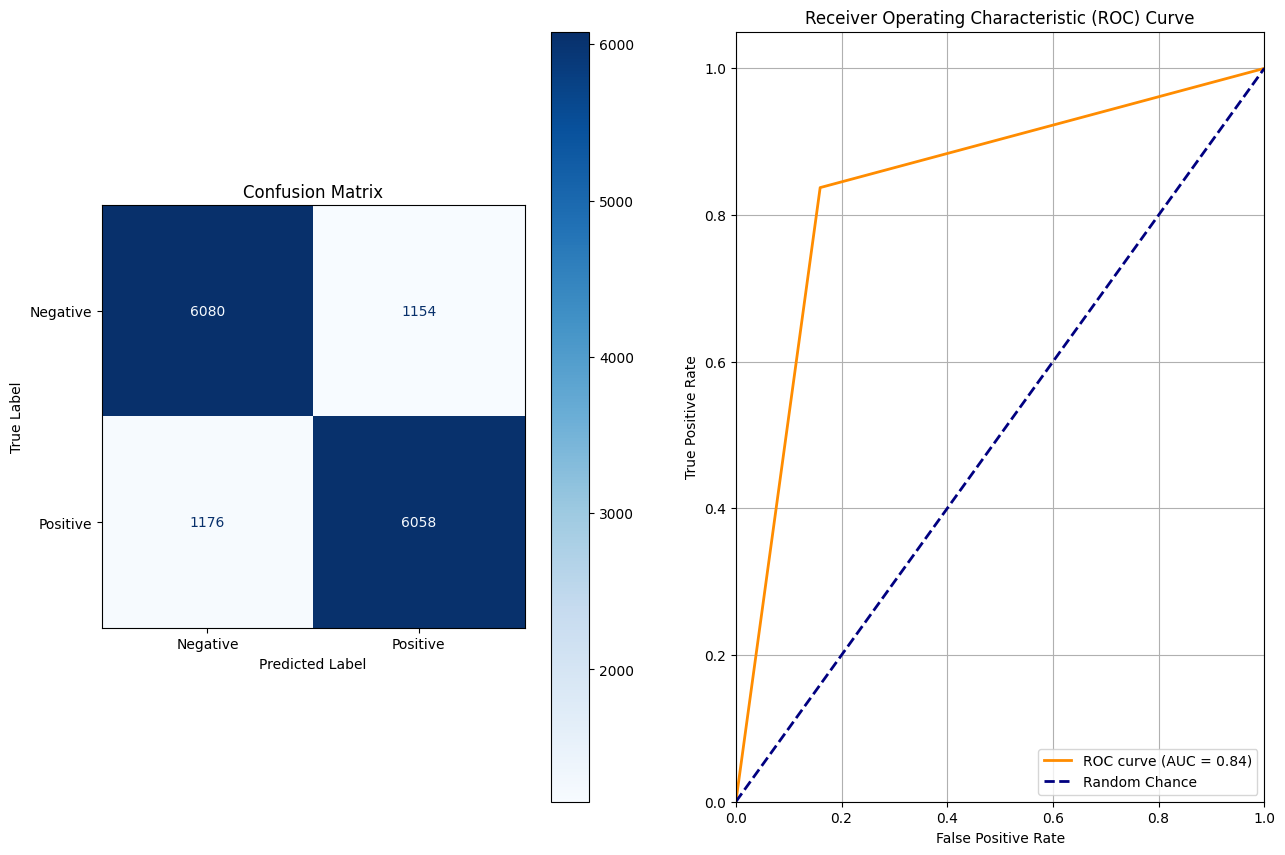

Inference Time: 63.74384903907776


In [161]:
batch_64_input_512_checkpoint = 'results/batch_64_input_512'

test_model(batch_64_input_512_checkpoint, val_data)

In [6]:
base_model_checkpoint = 'google-bert/bert-base-uncased'

batch_64_input_256 = ModelTrainer(base_model_checkpoint, dataset, 256, 3, batch_size=64, path = 'batch_64_input_256')
batch_64_input_256.train()

Map: 100%|██████████| 15000/15000 [00:00<00:00, 46089.50 examples/s]
/home/water/Grad School/DSE6212/.venv/lib/python3.12/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


{'loss': 0.4208, 'grad_norm': 2.379753351211548, 'learning_rate': 3.476538695917124e-05, 'epoch': 0.9140767824497258}
{'loss': 0.2643, 'grad_norm': 3.7858972549438477, 'learning_rate': 1.956124314442413e-05, 'epoch': 1.8281535648994516}
{'loss': 0.1482, 'grad_norm': 5.574306964874268, 'learning_rate': 4.326630103595368e-06, 'epoch': 2.742230347349177}
{'train_runtime': 93.7396, 'train_samples_per_second': 1120.124, 'train_steps_per_second': 17.506, 'train_loss': 0.2649178850730696, 'epoch': 3.0}


Number of Positive Predictions: 7083
Number of Negative Predictions: 7385
Percent Positive Predictions: 48.95631739010229
Percent Negative Predictions: 51.0436826098977

Accuracy: 83.86%

Recall: 0.8281725186618745

Precision: 0.8458280389665396

F1-Score: 0.84


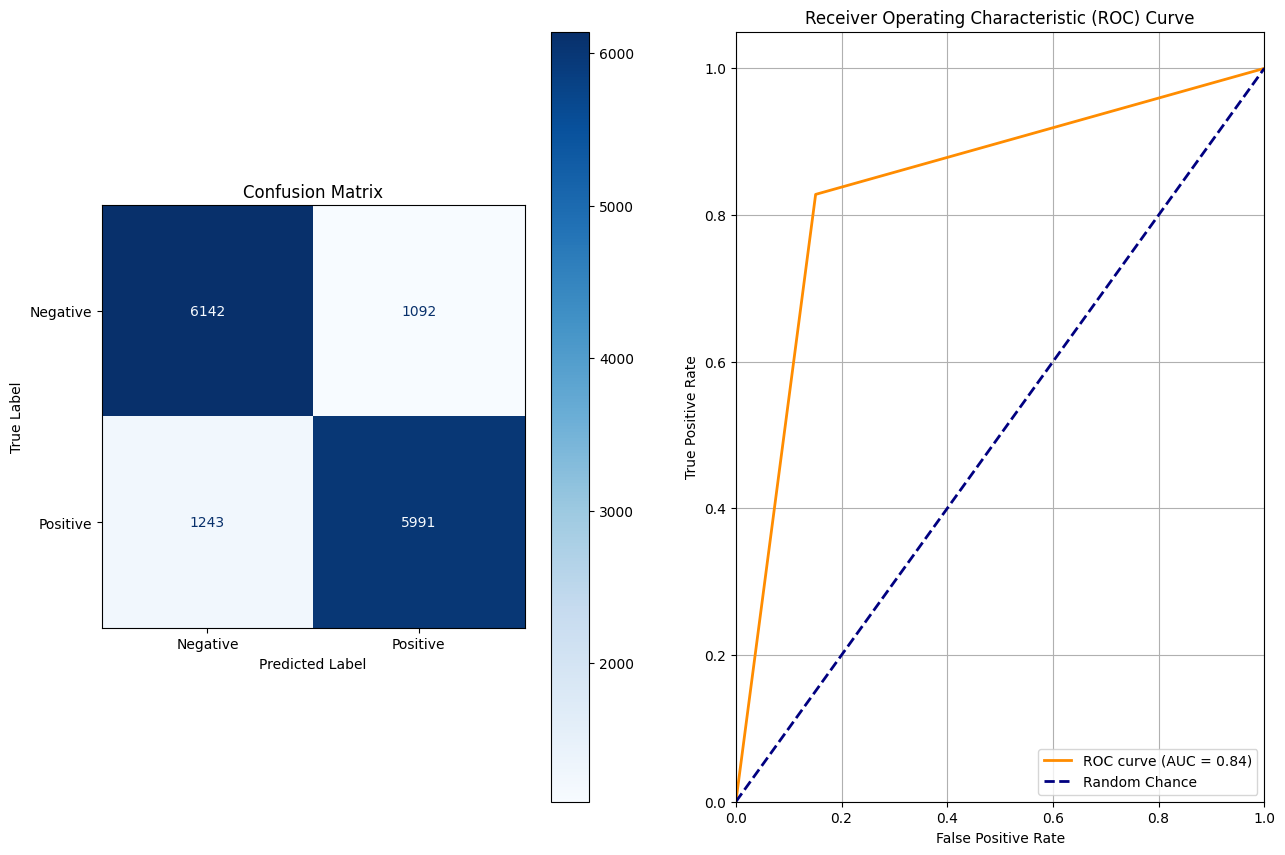

Inference Time: 58.62316584587097


In [13]:
batch_64_input_256_checkpoint = 'results/batch_64_input_256'

test_model(batch_64_input_256_checkpoint, val_data)

In [14]:
base_model_checkpoint = 'google-bert/bert-base-uncased'

batch_64_input_128 = ModelTrainer(base_model_checkpoint, dataset, 128, 3, batch_size=64, path = 'batch_64_input_128')
batch_64_input_128.train()

Map: 100%|██████████| 15000/15000 [-00:01<00:00, -8355.71 examples/s]
/home/water/Grad School/DSE6212/.venv/lib/python3.12/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


{'loss': 0.426, 'grad_norm': 2.6738085746765137, 'learning_rate': 3.476538695917124e-05, 'epoch': 0.9140767824497258}
{'loss': 0.2714, 'grad_norm': 3.457587718963623, 'learning_rate': 1.956124314442413e-05, 'epoch': 1.8281535648994516}
{'loss': 0.1508, 'grad_norm': 4.072437286376953, 'learning_rate': 4.326630103595368e-06, 'epoch': 2.742230347349177}
{'train_runtime': 97.7556, 'train_samples_per_second': 1074.108, 'train_steps_per_second': 16.787, 'train_loss': 0.2697735960203144, 'epoch': 3.0}


Number of Positive Predictions: 7309
Number of Negative Predictions: 7159
Percent Positive Predictions: 50.51838540226707
Percent Negative Predictions: 49.48161459773293

Accuracy: 83.71%

Recall: 0.8422726016035389

Precision: 0.8336297715145711

F1-Score: 0.84


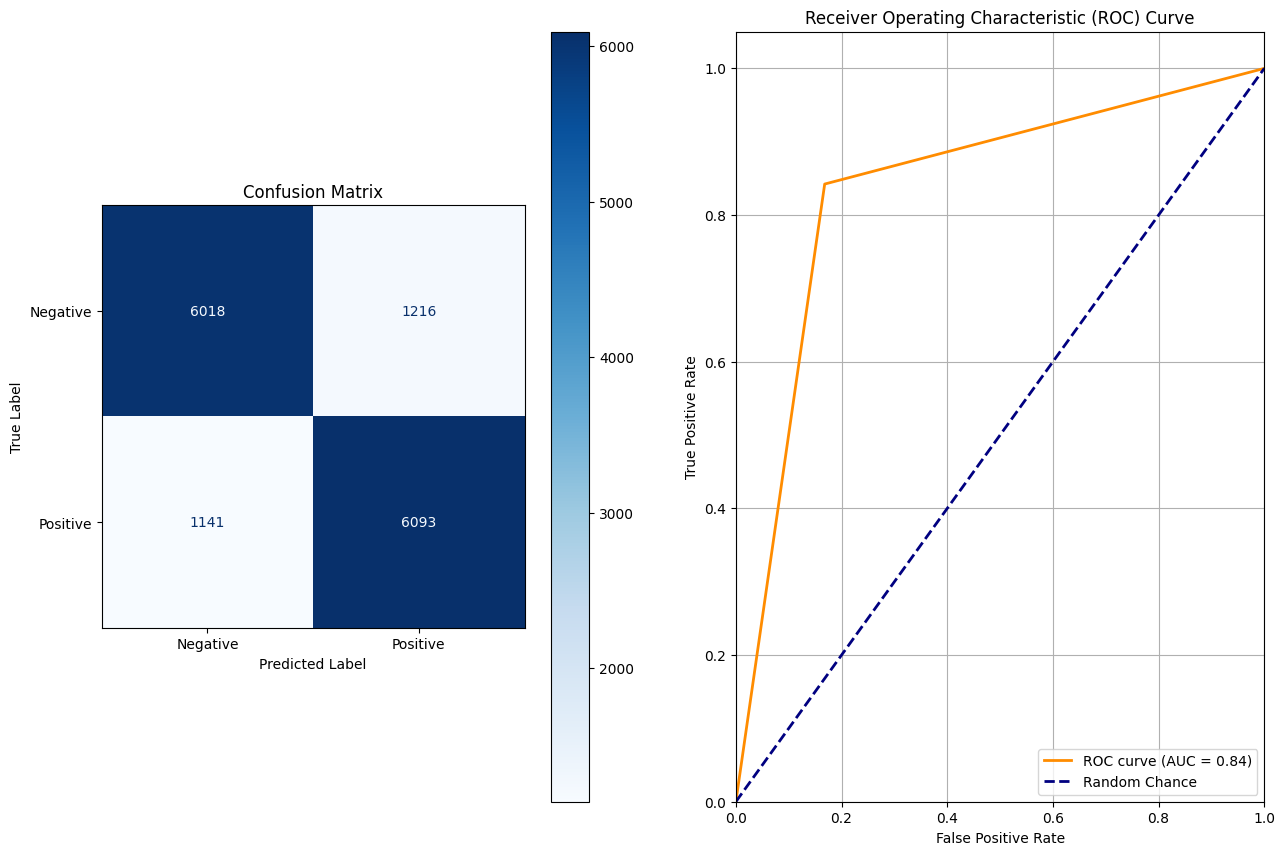

Inference Time: 61.456308364868164


In [15]:
batch_64_input_128_checkpoint = 'results/batch_64_input_128'

test_model(batch_64_input_128_checkpoint, val_data)

# Test Layer Freezing

In [ ]:
base = 'google-bert/bert-base-uncased'
model = BertForSequenceClassification.from_pretrained(base)

<generator object Module.named_parameters at 0x7b8d6e101a40>

In [19]:
for name, param in model.named_parameters():
    print(name)

bert.embeddings.word_embeddings.weight
bert.embeddings.position_embeddings.weight
bert.embeddings.token_type_embeddings.weight
bert.embeddings.LayerNorm.weight
bert.embeddings.LayerNorm.bias
bert.encoder.layer.0.attention.self.query.weight
bert.encoder.layer.0.attention.self.query.bias
bert.encoder.layer.0.attention.self.key.weight
bert.encoder.layer.0.attention.self.key.bias
bert.encoder.layer.0.attention.self.value.weight
bert.encoder.layer.0.attention.self.value.bias
bert.encoder.layer.0.attention.output.dense.weight
bert.encoder.layer.0.attention.output.dense.bias
bert.encoder.layer.0.attention.output.LayerNorm.weight
bert.encoder.layer.0.attention.output.LayerNorm.bias
bert.encoder.layer.0.intermediate.dense.weight
bert.encoder.layer.0.intermediate.dense.bias
bert.encoder.layer.0.output.dense.weight
bert.encoder.layer.0.output.dense.bias
bert.encoder.layer.0.output.LayerNorm.weight
bert.encoder.layer.0.output.LayerNorm.bias
bert.encoder.layer.1.attention.self.query.weight
bert.enc

In [31]:
trainable_layers = [
    "bert.encoder.layer.11",
    "bert.pooler",
    "classifier"
]

base_model_checkpoint = 'google-bert/bert-base-uncased'

encoder_11_pooler_classifier = ModelTrainer(base_model_checkpoint, dataset, 512, 3, batch_size=64, trainable_layers=trainable_layers, path = 'encoder_11_pooler_classifier')
encoder_11_pooler_classifier.train()

Map: 100%|██████████| 15000/15000 [00:00<00:00, 29339.59 examples/s]
/home/water/Grad School/DSE6212/.venv/lib/python3.12/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


{'loss': 0.4788, 'grad_norm': 1.0469681024551392, 'learning_rate': 3.476538695917124e-05, 'epoch': 0.9140767824497258}
{'loss': 0.424, 'grad_norm': 1.2131482362747192, 'learning_rate': 1.9530773918342475e-05, 'epoch': 1.8281535648994516}
{'loss': 0.4045, 'grad_norm': 2.0135324001312256, 'learning_rate': 4.296160877513712e-06, 'epoch': 2.742230347349177}
{'train_runtime': 34.0643, 'train_samples_per_second': 3082.409, 'train_steps_per_second': 48.174, 'train_loss': 0.4342940921539362, 'epoch': 3.0}


Number of Positive Predictions: 7238
Number of Negative Predictions: 7230
Percent Positive Predictions: 50.02764722145424
Percent Negative Predictions: 49.97235277854576

Accuracy: 82.06%

Recall: 0.8208460049764998

Precision: 0.820392373583863

F1-Score: 0.82


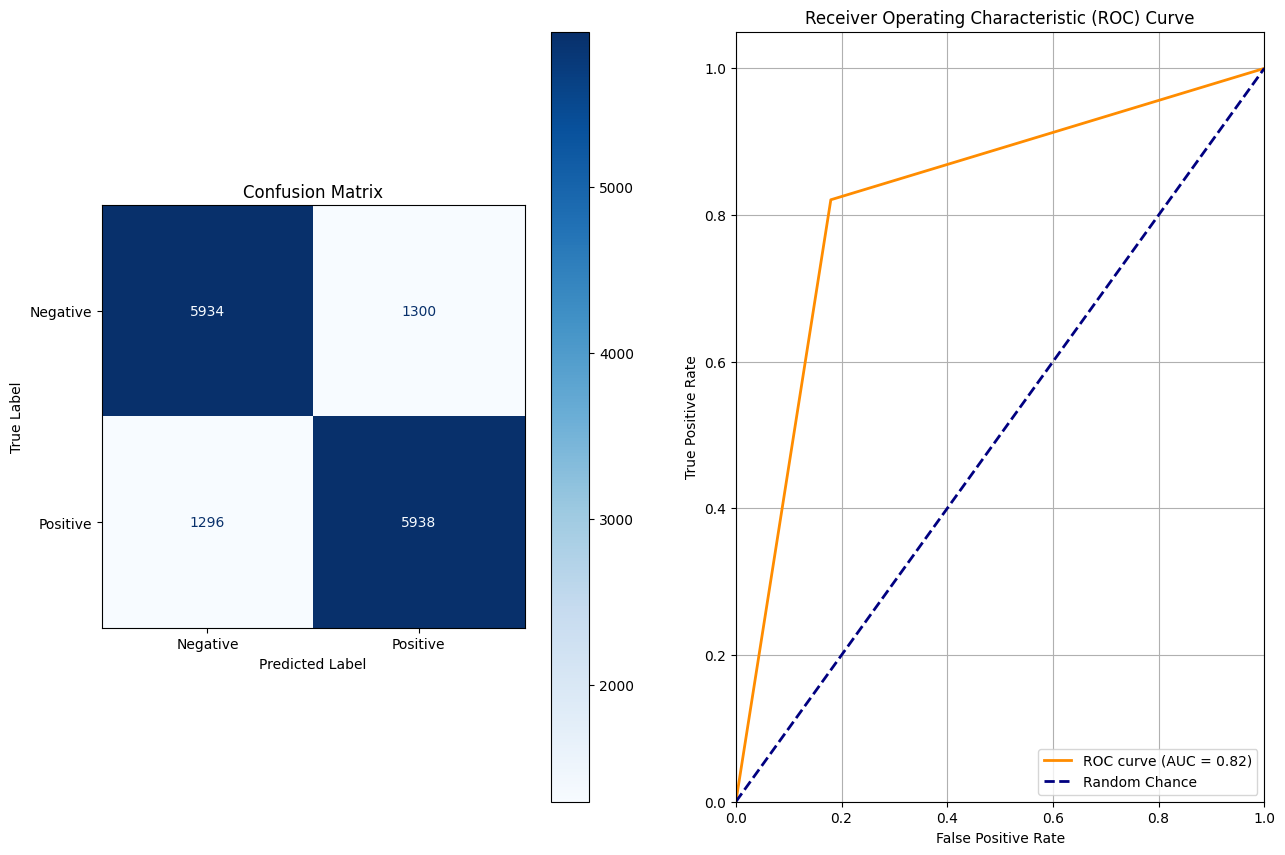

Inference Time: 61.564648151397705


In [32]:
encoder_11_pooler_classifier_checkpoint = 'results/encoder_11_pooler_classifier'

test_model(encoder_11_pooler_classifier_checkpoint, val_data)

In [22]:
trainable_layers = [
    "bert.encoder.layer.9",
    "bert.encoder.layer.10",
    "bert.encoder.layer.11",
    "bert.pooler",
    "classifier"
]

base_model_checkpoint = 'google-bert/bert-base-uncased'

encoder_9_10_11_pooler_classifier = ModelTrainer(base_model_checkpoint, dataset, 512, 3, batch_size=64, trainable_layers=trainable_layers, path = 'encoder_9_10_11_pooler_classifier')
encoder_9_10_11_pooler_classifier.train()

Map: 100%|██████████| 15000/15000 [00:00<00:00, 27159.38 examples/s]
/home/water/Grad School/DSE6212/.venv/lib/python3.12/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


{'loss': 0.4511, 'grad_norm': 1.3793076276779175, 'learning_rate': 3.47958561852529e-05, 'epoch': 0.9140767824497258}
{'loss': 0.3842, 'grad_norm': 1.6000316143035889, 'learning_rate': 1.956124314442413e-05, 'epoch': 1.8281535648994516}
{'loss': 0.3488, 'grad_norm': 1.9473614692687988, 'learning_rate': 4.326630103595368e-06, 'epoch': 2.742230347349177}
{'train_runtime': 40.6668, 'train_samples_per_second': 2581.957, 'train_steps_per_second': 40.352, 'train_loss': 0.39094357952557274, 'epoch': 3.0}


Number of Positive Predictions: 7141
Number of Negative Predictions: 7327
Percent Positive Predictions: 49.35720210118883
Percent Negative Predictions: 50.64279789881117

Accuracy: 83.03%

Recall: 0.8238871993364667

Precision: 0.8346170004201092

F1-Score: 0.83


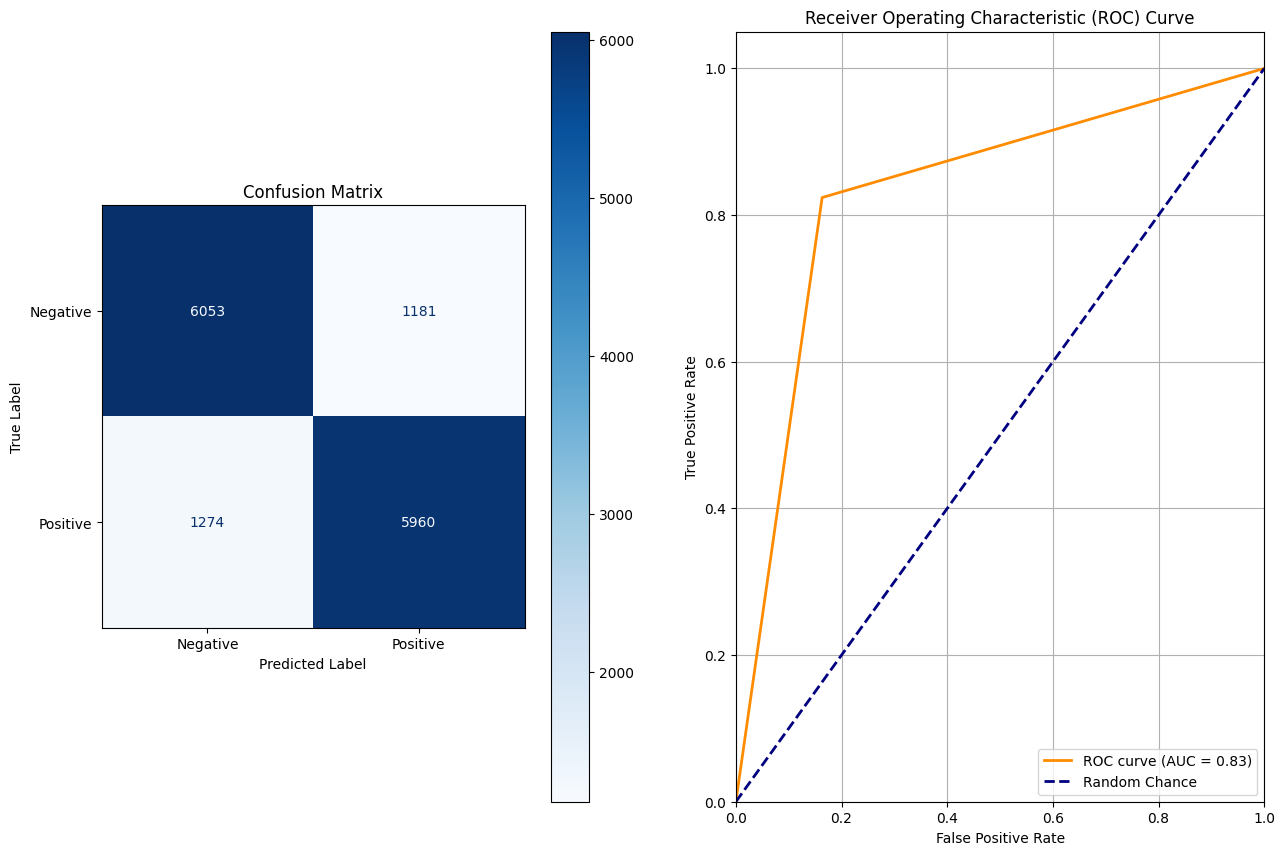

Inference Time: 61.97455596923828


In [23]:
encoder_9_10_11_pooler_classifier_checkpoint = 'results/encoder_9_10_11_pooler_classifier'

test_model(encoder_9_10_11_pooler_classifier_checkpoint, val_data)

In [76]:
trainable_layers = [
    "bert.encoder.layer.6",
    "bert.encoder.layer.7",
    "bert.encoder.layer.8",
    "bert.encoder.layer.9",
    "bert.encoder.layer.10",
    "bert.encoder.layer.11",
    "bert.pooler",
    "classifier"
]

base_model_checkpoint = 'google-bert/bert-base-uncased'

encoder_6_7_8_9_10_11_pooler_classifier_pre = ModelTrainer(base_model_checkpoint, dataset, 512, 3, batch_size=64, trainable_layers=trainable_layers, text_preprocess=True, path = 'encoder_6_7_8_9_10_11_pooler_classifier_pre')
encoder_6_7_8_9_10_11_pooler_classifier_pre.train()

Map: 100%|██████████| 15000/15000 [00:01<00:00, 13966.90 examples/s]
/home/water/Grad School/DSE6212/.venv/lib/python3.12/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


{'loss': 0.4295, 'grad_norm': 2.1268463134765625, 'learning_rate': 3.476538695917124e-05, 'epoch': 0.9140767824497258}
{'loss': 0.3294, 'grad_norm': 2.382455348968506, 'learning_rate': 1.9530773918342475e-05, 'epoch': 1.8281535648994516}
{'loss': 0.2576, 'grad_norm': 2.593918561935425, 'learning_rate': 4.326630103595368e-06, 'epoch': 2.742230347349177}
{'train_runtime': 58.2053, 'train_samples_per_second': 1803.958, 'train_steps_per_second': 28.193, 'train_loss': 0.3312623920708005, 'epoch': 3.0}


Number of Positive Predictions: 7036
Number of Negative Predictions: 7432
Percent Positive Predictions: 48.63146253801493
Percent Negative Predictions: 51.36853746198508

Accuracy: 83.58%

Recall: 0.8220901299419409

Precision: 0.845224559408755

F1-Score: 0.83


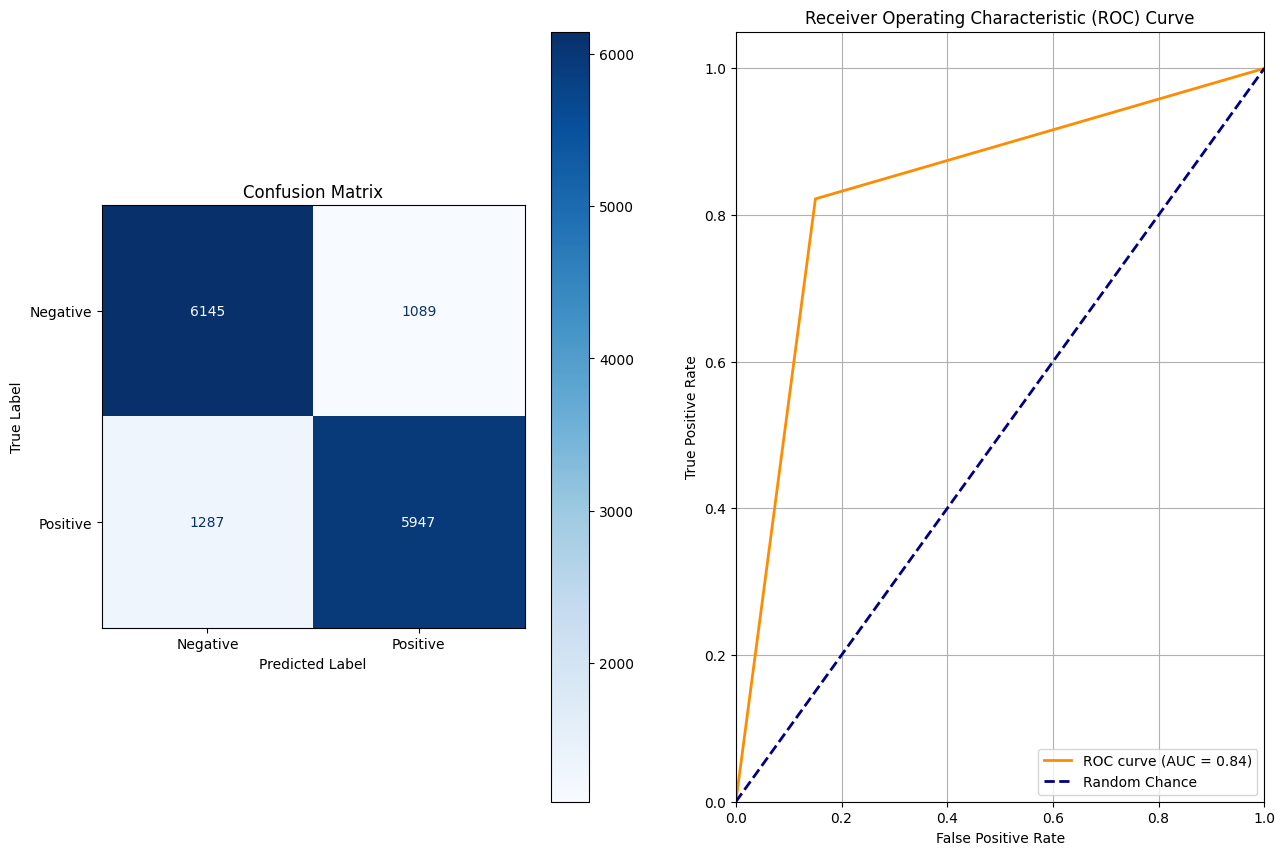

Inference Time: 63.944581031799316


In [77]:
encoder_6_7_8_9_10_11_pooler_classifier_pre_checkpoint = 'results/encoder_6_7_8_9_10_11_pooler_classifier_pre'

test_model(encoder_6_7_8_9_10_11_pooler_classifier_pre_checkpoint, val_data)

# See where the model is failing.

Number of Positive Predictions: 7187
Number of Negative Predictions: 7281
Percent Positive Predictions: 49.67514514791264
Percent Negative Predictions: 50.32485485208736

Accuracy: 83.65%

Recall: 0.8332872546309096

Precision: 0.8387366077640184

F1-Score: 0.84


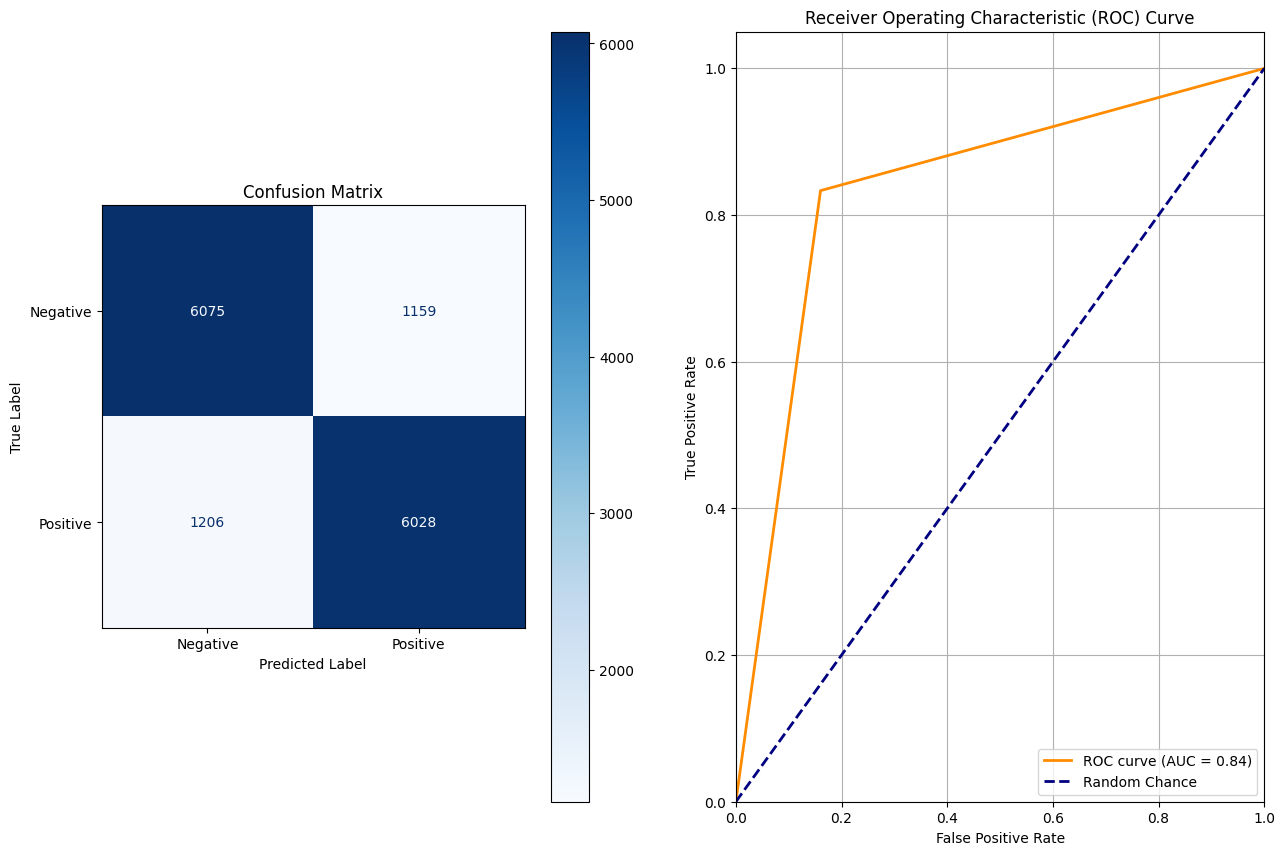

Inference Time: 69.35658717155457


In [67]:
encoder_6_7_8_9_10_11_pooler_classifier_checkpoint = 'results/encoder_6_7_8_9_10_11_pooler_classifier'

model_results = test_model(encoder_6_7_8_9_10_11_pooler_classifier_checkpoint, val_data)

In [70]:
model_results.false_positives[0:25]

["These people are eating burgers and I'm fucking starving  I can smell their chips",
 "@yoitsandrea There's a difference between making fun of you and thinking that the picture was funny though. Sorry. ",
 '@aisfornala Oh. So people laugh at me huh?  Your words are like an ice dagger to my heart etc etc ;)',
 'on my way to a roseville, mn corporate sprint store... hope im not to late for a pre ',
 'wants to stay in bermondsey park with an ice pop ',
 "..kids on the pc ..i have to share  i can't wait until my @alienware gets here next month _ ID4 at @furiousstudios &quot;ET phone home&quot; lol",
 " didn't get an award but i did get recognized by all the seniors. They said that they are going to watch the plays because of me ",
 "@Cheeg she's really into it. I bought it her last night and she's not stop playing it all day. I think she likes the virtual me better ",
 'Flu in the summer. Gay in the face. Bed for me I think ',
 '@kortni_alys it scarcely counts as a nap ',
 "Eating the las

In [71]:
model_results.false_negatives[0:25]

['@RealDeal32 NO! ',
 "So it turns out my bank card doesn't work here. This is working out to be a very cheap holiday  faith no more in two hours! Woot!",
 'And Santa and the Toothfairy dont exist  By the way doggy paddle is a legitimate way to keep balance  x',
 '@anastasiat do i still win if I do all 20 replys? ',
 '@foleypod Changing careers anyway. Less work, more money ',
 '@darlinejasmin Whoa, another keeper. I really understand this. If know how I feel no matter what I feel, I then feel better!!  thnx',
 '@BReal_2 : MAN any event that is hosted by Remy is the Shit!  I can not believe i forgot about tonight damn vice bass,,,lol: HI VINCE ',
 'When my Bottle Pop Shake me!.. ',
 'Enjoying the heck out of spending time with Amanda.  Do i really have to go back tomorrow?',
 '#flylady this beautiful weather is making me completely LAZY lol.....ds2 napping making lunch for ds10 &amp; I need to start something ',
 "when I say 'far away', I meant I threw away my copy ",
 "STILL HAVEN'T B

Number of Positive Predictions: 7036
Number of Negative Predictions: 7432
Percent Positive Predictions: 48.63146253801493
Percent Negative Predictions: 51.36853746198508

Accuracy: 83.58%

Recall: 0.8220901299419409

Precision: 0.845224559408755

F1-Score: 0.83


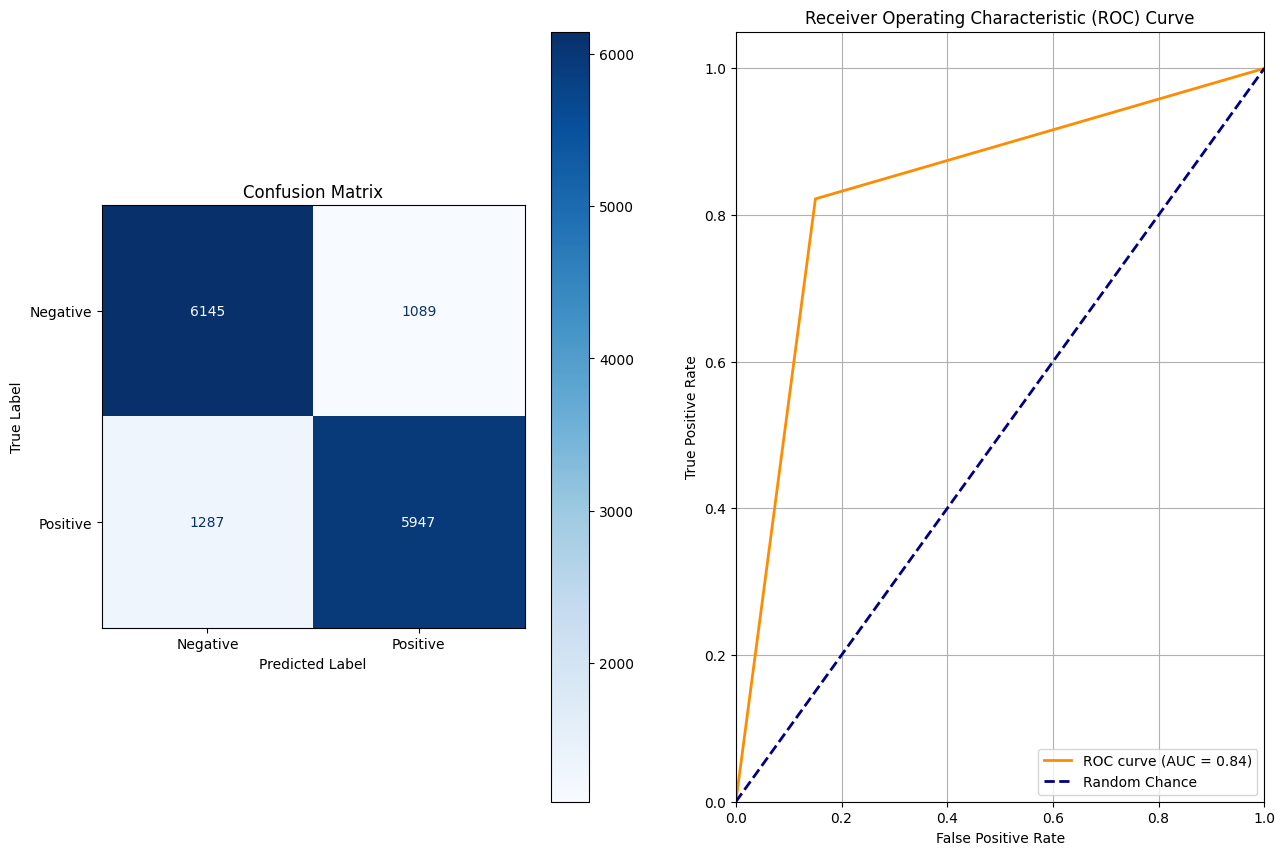

Inference Time: 62.764851331710815


In [78]:
encoder_6_7_8_9_10_11_pooler_classifier_pre_checkpoint = 'results/encoder_6_7_8_9_10_11_pooler_classifier_pre'

model_results_pre = test_model(encoder_6_7_8_9_10_11_pooler_classifier_pre_checkpoint, val_data)

In [81]:
model_results_pre.false_positives[0:25]

["These people are eating burgers and I'm fucking starving  I can smell their chips",
 "@yoitsandrea There's a difference between making fun of you and thinking that the picture was funny though. Sorry. ",
 ': should I go to the party or not? ',
 "..kids on the pc ..i have to share  i can't wait until my @alienware gets here next month _ ID4 at @furiousstudios &quot;ET phone home&quot; lol",
 "@Cheeg she's really into it. I bought it her last night and she's not stop playing it all day. I think she likes the virtual me better ",
 'Flu in the summer. Gay in the face. Bed for me I think ',
 "Eating the last of my &quot;green stuff&quot; (ie Watergate salad).    May make some more tonight as it's really good!",
 '@firstshowing Clash of the Titans remake??! nnnnnnnnoooooooo  ',
 '@vytnguyen wine and a movie by yourself ',
 "@verwon yes  I can't wait til tomorrow night. Then I'll just have one more and it's easy.",
 'working inside all day on this sunny hot beautiful day ',
 'late night pho

In [82]:
model_results_pre.false_negatives[0:25]

['@RealDeal32 NO! ',
 "So it turns out my bank card doesn't work here. This is working out to be a very cheap holiday  faith no more in two hours! Woot!",
 'And Santa and the Toothfairy dont exist  By the way doggy paddle is a legitimate way to keep balance  x',
 '@anastasiat do i still win if I do all 20 replys? ',
 '@foleypod Changing careers anyway. Less work, more money ',
 '@darlinejasmin Whoa, another keeper. I really understand this. If know how I feel no matter what I feel, I then feel better!!  thnx',
 'When my Bottle Pop Shake me!.. ',
 'Enjoying the heck out of spending time with Amanda.  Do i really have to go back tomorrow?',
 '#flylady this beautiful weather is making me completely LAZY lol.....ds2 napping making lunch for ds10 &amp; I need to start something ',
 "when I say 'far away', I meant I threw away my copy ",
 '@iamjonathancook must go to strawberry fields!! ',
 '@wendyperrin Count me in as one of the suscribers (although I am in the industry) ',
 "STILL HAVEN'T 